In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("C:/Users/Rayansh/Desktop/IPL-DATA/heart.csv")

In [4]:
updated_df=df

In [6]:
updated_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
updated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [11]:
from sklearn.linear_model import LinearRegression
X = updated_df[['age']]
Y = updated_df['thalach']

0.15227717008771258

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size=0.20, random_state=42)
X_train
Y_train
X_test
Y_test

527    163
359    115
447    145
31     162
621    150
      ... 
832    151
796    132
644    169
404    138
842    165
Name: thalach, Length: 205, dtype: int64

In [16]:
reg = LinearRegression().fit(X,Y)
reg.score(X,Y)

0.15227717008771258

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol']
X = updated_df[feature_cols]
y = updated_df['target']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
clf = LogisticRegression(penalty='l2', C=1.0, solver='liblinear', random_state=42, max_iter=1000)
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7219512195121951
Precision: 0.7352941176470589
Recall: 0.7142857142857143
F1: 0.7246376811594203
ROC AUC: 0.8101904761904762
Confusion matrix:
 [[73 27]
 [30 75]]


In [35]:
import matplotlib.pyplot as plt

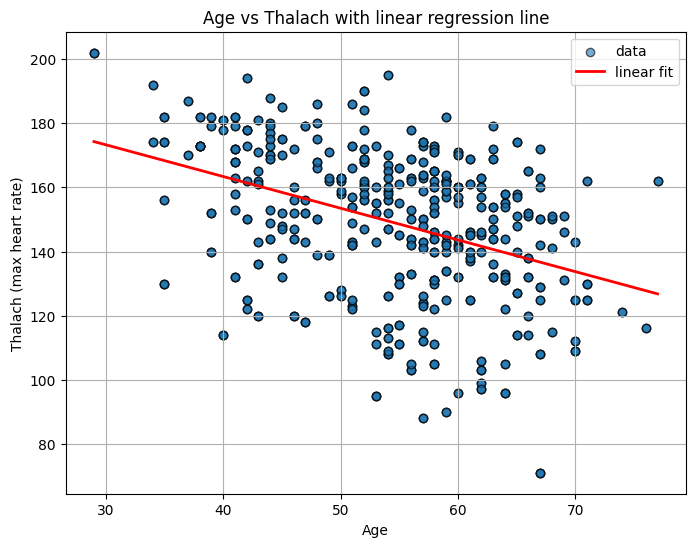

In [39]:
X = updated_df['age'].to_numpy()         # 1-D array
y = updated_df['thalach'].to_numpy()     # 1-D array

reg.fit(X.reshape(-1, 1), y)
y_pred_line = reg.predict(X.reshape(-1, 1))

plt.figure(figsize=(8,6))
plt.scatter(X, y, alpha=0.6, edgecolor='k', label='data')
plt.plot(np.sort(X), y_pred_line[np.argsort(X)], color='red', linewidth=2, label='linear fit')
plt.xlabel('Age')
plt.ylabel('Thalach (max heart rate)')
plt.title('Age vs Thalach with linear regression line')
plt.legend()
plt.grid(True)
plt.show()

ROC AUC: 0.8101904761904762


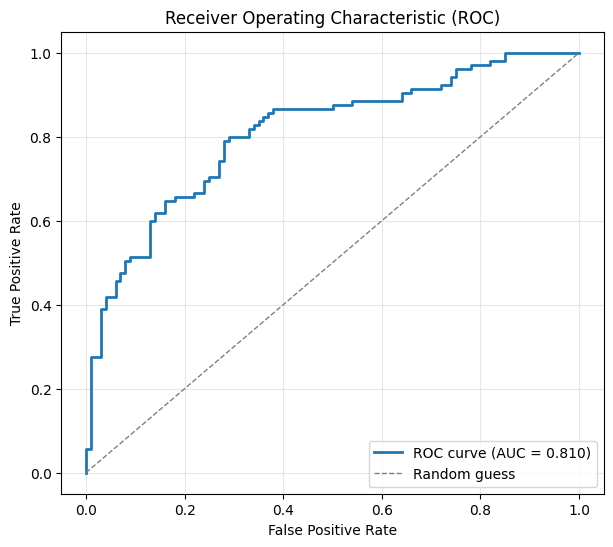

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_value = roc_auc_score(y_test, y_proba)
print("ROC AUC:", auc_value)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='C0', lw=2, label=f'ROC curve (AUC = {auc_value:.3f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()